In [6]:
import sys
sys.path.append('../../../../src')
sys.path.append('../../../..')

import os
from dataclasses import replace

from PIL import ImageFont
import matplotlib.pyplot as plt
import numpy as np
from palette.symbol2value import get_asciis
from converters.img_converter import ImgConverter
from converters.line_heuristics.line_converter import LineConverter
from converters.tile.bin_2d import Tile2Symb2dBin

from tests.experimental.test_loop import Params, test_loop

SYMBOLS = get_asciis()
FONT_PATH = "../../../../fonts/FiraCode-Regular.ttf"
FONT_SIZE = 10
FONT = ImageFont.truetype(FONT_PATH, FONT_SIZE)
MAX_COLS = 20
MAX_LINES = 10
NUM_IMGS = 10
IMG_SET_PATH = "../../../../imgs/BSDS500-ds"
IMG_PATHS = [os.path.join(IMG_SET_PATH, img_name)
             for img_name in os.listdir(IMG_SET_PATH)[:NUM_IMGS]]


def make_converter(params: Params):
    converter = LineConverter(tile_converter=Tile2Symb2dBin(symbols=SYMBOLS,
                                                            font=FONT,
                                                            **params.converter_args))

    return ImgConverter(converter, FONT)

In [7]:
from PIL import Image
from image.processing import preprocess_img
from rendering.terminal import print_gallery

default_params = Params(max_cols=MAX_COLS,
                        max_lines=MAX_LINES,
                        font_path=FONT_PATH,
                        font_size=FONT_SIZE)

converter = make_converter(default_params)

line_height = int(default_params.font_size * 1.333)
col_width = int(line_height / 2)

results = []
for img_path in IMG_PATHS[:6]:
    img = Image.open(img_path).convert("L")
    img = preprocess_img(img, contrast=1.7)
    res_arr = converter.img2symbols(img,
                                    max_cols=MAX_COLS,
                                    max_lines=MAX_LINES,
                                    col_width=col_width,
                                    line_height=line_height,
                                    gens_per_step=default_params.gens_per_step)
    results.append(res_arr)

print_gallery(results, 3)

----------------------------------------------------------------------
| ^^""?lv}l?""7*/!==~` | S#R%QwDZC$wQWW@@S$W# | PPRRT!:=:ueo3LsVP?~` |
| qqqqqqqqqquuqu;;;;__ | ?*7o$w$Z+F?R#d*fl*Y: | 4icLL+L7*lcc:::::::. |
| $QQQ@%##%QQQQQQQQQ$w | u]ZZ$$Z?"'` *]eeZGZv | r(s55Z0&#W%OmajwQ%$A |
| $QQWM;uu;ZQQQQ$$$$$& | kZeZ$$$Z.`  LGwG6RH* | (x{(L""?l5KCh33l:!P^ |
| $$QQQQQQ@@@@QQQ$$$OS | L6UKb$$d<`  [ZZ&%qZL | nJ|zv`~\:?:``'=:=:;, |
| $@@@@@@@@@@WWQQQ$$de | ZeZe8O$$n`.ul'"FZeKh | >\c*!`/::.:,;uyZd0D6 |
| ^^"^""^^^"^""""^^''' | ''''''""  ''   `'''' | `     ''''''''''''^' |
----------------------------------------------------------------------
-----------------------------------------------------------------
|  ```` `` ` ` `  | QwM$8%QQqeZgW@guaqw$ | ZZyuL>LKV9SdZZZZeZ]c |
| `````.:``:````` | Q@QW%R##W$$ORR###MWW | 0#RRRZjJ\<[oZTli*?Yl |
| ZeZK6SUeeeZeeZ- | eMQ@@Qgwqwh?cP?='^"R | wqqac]lvkYkA&erzuuyJ |
| G&&GbAbA&G&&KU- | #RRW@W%%P`'>?' ````` | b$$$##Z}'`:eZqqD&ee1 |
| ZZZGbtZCcZAZZZ- | 4E)??PP#;uP

Min: 0.0250 | Max: 0.0894 | Mean: 0.0544 | Std: 0.0220
Min: 0.0418 | Max: 0.1363 | Mean: 0.0936 | Std: 0.0263
Min: 0.0958 | Max: 0.1582 | Mean: 0.1246 | Std: 0.0226
Min: 0.0368 | Max: 0.1788 | Mean: 0.1240 | Std: 0.0412
Min: 0.0586 | Max: 0.1691 | Mean: 0.1165 | Std: 0.0307
Min: 0.0625 | Max: 0.1893 | Mean: 0.1294 | Std: 0.0341
Min: 0.0544 | Max: 0.1742 | Mean: 0.1206 | Std: 0.0326
Min: 0.0766 | Max: 0.1888 | Mean: 0.1232 | Std: 0.0298
Min: 0.0738 | Max: 0.1817 | Mean: 0.1257 | Std: 0.0297


C:\Users\wojte\AppData\Local\Temp\ipykernel_17440\910520446.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


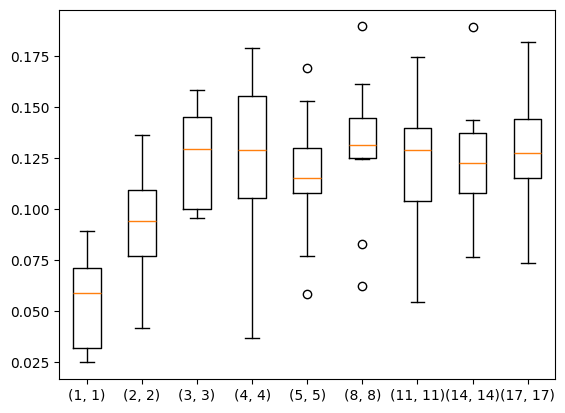

In [8]:
# bins

params_space = [
    (bins, bins) for bins in range(1, 5, 1)
]
params_space += [
    (bins, bins) for bins in range(5, 18, 3)
]

params_space = list(
    map(lambda bins: replace(default_params, converter_args={'bins': bins}),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.converter_args['bins'] for param in params_space])
plt.show()

Min: 0.0358 | Max: 0.1279 | Mean: 0.0877 | Std: 0.0237
Min: 0.0577 | Max: 0.1538 | Mean: 0.1114 | Std: 0.0257
Min: 0.0533 | Max: 0.1892 | Mean: 0.1353 | Std: 0.0380
Min: 0.0483 | Max: 0.2187 | Mean: 0.1543 | Std: 0.0506
Min: 0.0666 | Max: 0.2396 | Mean: 0.1688 | Std: 0.0530


C:\Users\wojte\AppData\Local\Temp\ipykernel_17440\2305421242.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


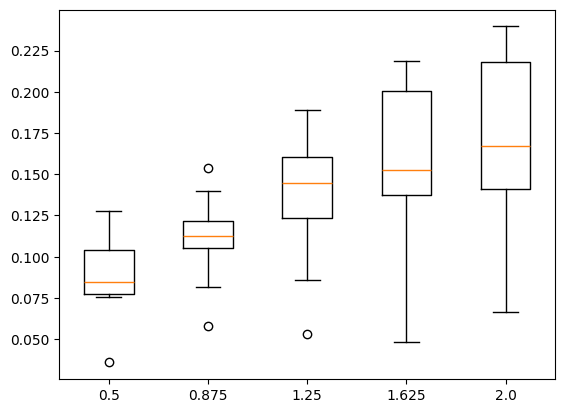

In [9]:
# contrast

params_space = [
    {'contrast': c} for c in np.linspace(0.5, 2.0, 5, endpoint=True)
]

params_space = list(
    map(lambda preprocess_args: replace(default_params, preprocess_args=preprocess_args),
        params_space))

similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=[param.preprocess_args['contrast'] for param in params_space])
plt.show()

Min: 0.0534 | Max: 0.1740 | Mean: 0.1141 | Std: 0.0299
Min: 0.0535 | Max: 0.1032 | Mean: 0.0852 | Std: 0.0145
Min: 0.0210 | Max: 0.3649 | Mean: 0.1516 | Std: 0.0978


C:\Users\wojte\AppData\Local\Temp\ipykernel_17440\1162874657.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(similarity_scores,


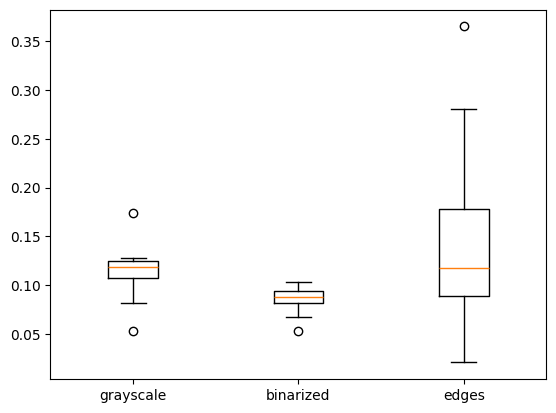

In [10]:
params_space = [default_params]
similarity_scores = test_loop(IMG_PATHS, make_converter, params_space)

IMG_BIN_SET_PATH = "../../../../imgs/BSDS500-ds-bin"
IMG_BIN_PATHS = [os.path.join(IMG_BIN_SET_PATH, img_name)
             for img_name in os.listdir(IMG_BIN_SET_PATH)[:NUM_IMGS]]

similarity_scores += test_loop(IMG_BIN_PATHS, make_converter, params_space)

IMG_EDGE_SET_PATH = "../../../../imgs/BSDS500-ds-edge-bin"
IMG_EDGE_PATHS = [os.path.join(IMG_EDGE_SET_PATH, img_name)
             for img_name in os.listdir(IMG_EDGE_SET_PATH)[:NUM_IMGS]]

similarity_scores += test_loop(IMG_EDGE_PATHS, make_converter, params_space)

plt.boxplot(similarity_scores,
            labels=['grayscale', 'binarized', 'edges'])
plt.show()